## Day 9 (2026-04-28) — Composite cell physics + sign-reversal mechanism analysis

### Stage 2: Chen2020_composite HPPC characterization
A 16-case HPPC sweep (SOC ∈ {20, 30, …, 90} % × {discharge, charge}) was executed
on the `Chen2020_composite` parameter set with `("single", "current sigmoid")`
OCP options, replicating the Day 8 single-phase HPPC protocol on a Si–graphite
blend electrode. The discharge branch yielded `tau2_biexp` ranging
36.7–90.8 s (median 53.2 s), in close agreement with the Day 8 single-phase
discharge median of 45.4 s. The charge branch, in contrast, produced
non-monotonic relaxation traces in which the post-pulse voltage first decays
then partially recovers — a signature of the current-sigmoid hysteresis switching
the active OCV branch during rest. Bi-exponential fitting collapsed
(R² ≈ 0, τ pinned at the 1500 s upper bound) for all eight charge-direction
cases. The composite charge median therefore cannot be defined under the
Day 8 fitting protocol; only the discharge median (53.2 s) is retained as a
Chen2020-side time-constant estimate. Day 8 single-phase τ_Chen
(charge median, 60 s window) of 23.8 s remains the value used for any
frequency-rescaling analysis to preserve methodological symmetry with the
MJ1 60 s rest experimental protocol.

### Sign-agreement final tally on the v0.1 case set (24 unique conditions)

| Configuration | Sign agreement vs MJ1 experiment |
|---|---|
| v0.1 SPMe + V_init = 2.51 V (Day 6) | 12 / 23 ≈ 52.2 % |
| X2 — DFN + V_init = 2.51 V (Day 8) | 11 / 23 ≈ 47.8 % |
| X5-A — DFN + V_init = 2.82 V, optimized init protocol (Day 8) | **15 / 24 ≈ 62.5 %** |
| X6α — composite + sigmoid + V_init forced (Day 9) | 1 / 15 ≈ 6.7 % |
| X6β-v2 — composite + sigmoid + natural rest, true φ=0 (Day 9) | 3 / 15 ≈ 20.0 % |

The X5-A configuration is the strongest PyBaMM reproduction of the experimental
sign pattern available to date. Adding a Si-secondary phase together with a
current-sigmoid hysteresis switch degrades agreement by ≥ 40 percentage
points across two protocol variants, confirming that composite + sigmoid in
PyBaMM systematically fails for DC + AC superimposed charging regardless of
V_init protocol.

### Frequency-mismatch hypothesis ruled out

A candidate explanation for the residual 9 / 24 sign-mismatched cases under
X5-A was that MJ1-derived frequencies do not sample Chen2020's intrinsic
relaxation-time band. Trajectory-level analysis of the κ = 1.5 cluster
(`0.2C + 0.3C` at τ-labels {1τ, 10τ, 34.8τ}, which all fail under X5-A)
disproves this. Three observations:

1. **Failures span all three τ-labels** (frequencies 0.0143, 0.00143,
   0.000412 Hz — two decades apart). If FMH were dominant, sign-mismatch
   would cluster on a frequency band, not span it.
2. **Q_net(t) reaches Q80 = 4101 mAh later in sim than in the 0.2C-DC
   reference** (sim Δt ∈ {−0.58, −5.30, −2.15} min — note Day 8 sign
   convention `Δt = t_ref − t_sim`, so negative Δt means simulation slower
   than reference). The MJ1 experiment shows the opposite: AC injection
   accelerates the time to Q80 (exp Δt = +0.17, +5.05, +15.03 min).
   This is not a quantitative mismatch but a categorical reversal of the
   AC effect direction.
3. **The Q_net oscillation amplitude in sim is large** (≈ 200 mAh peak-to-peak
   for 0.2 + 0.3C at 10τ, visible as a sawtooth around the linear ramp),
   yet the AC peaks fail to break through Q80 ahead of the ref. The
   simulated cell carries the AC oscillation as superimposed signal on a
   marginally retarded mean trajectory, rather than as a kinetically
   enhanced net charging rate.

The mismatch therefore does not originate in the frequency grid but in the
absence, within DFN + Chen2020 parameters, of an AC-coupled nonlinearity
that the real MJ1 cell exhibits — most plausibly involving lithium-plating
threshold modulation, Si–graphite intercalation kinetic asymmetry under
modulated current, or double-layer / interfacial dynamics outside the
Butler–Volmer formulation. Standard PyBaMM physics in the κ ≳ 1
low-DC, mid-AC regime cannot reproduce the experimentally observed AC
charging acceleration; this defines the present model-physics ceiling
of the v0.x sweep.

### Methodological notes (locked-in for future analysis)

- `Δt(Q80)` is computed via `t_ref − t_sim` with `Q80 = 4101 mAh`
  (= 80 % of Chen2020 nominal max usable capacity 5126 mAh, not 80 % of
  5 Ah label).
- The `first_passage_interp` algorithm (linear-interpolated first crossing
  of `Q_net ≥ Q_target` on the strict-net signed integral) is the canonical
  Δt(Q\*) extractor across Day 6, 7, 8 batches and matches CSV records to
  within ≤ 0.005 min per case.
- Frequency rescaling for cross-cell comparison should use τ values
  measured under matched fitting-window length. The 60 s-window
  Chen2020 single-phase charge median (23.8 s) is the appropriate
  counterpart to MJ1's 60 s-rest experimental τ_ref (20.3 s); the 5000 s
  window value (47.0 s) is window-asymmetric and not directly comparable.

In [2]:
# ============================================================
# Cell 1: HPPC composite+sigmoid — single SOC=50% discharge sanity
# ============================================================
import pybamm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
import time
import json
import warnings
warnings.filterwarnings("ignore")

print(f"PyBaMM: {pybamm.__version__}")

NOMINAL_CAP_AH = 5.0
T_AMB_C = 20.0

def build_composite_sigmoid_model_params(T_amb_C=T_AMB_C):
    """Chen2020_composite + sigmoid hysteresis, isothermal (no lumped thermal)."""
    model = pybamm.lithium_ion.DFN(options={
        "particle phases": ("2", "1"),
        "open-circuit potential": (("single", "current sigmoid"), "single"),
        # NO thermal — composite lacks unified density key
    })
    params = pybamm.ParameterValues("Chen2020_composite")
    params.update({"Ambient temperature [K]": T_amb_C + 273.15})
    params.update({"Initial temperature [K]": T_amb_C + 273.15})
    return model, params


def run_hppc_single_case_composite(
    soc_target: float,           # e.g. 0.5
    direction: str,              # "discharge" or "charge"
    rest_pre_s: float = 5000.0,
    rest_post_s: float = 5000.0,
    pulse_duration_s: float = 10.0,
    pulse_C_rate: float = 1.0,
    nominal_capacity_Ah: float = NOMINAL_CAP_AH,
    verbose: bool = True,
):
    """One HPPC case: full P1 protocol (1C-dis-CV → rest 600s → 1C charge to SOC →
    rest pre → 1C pulse → rest post). Returns full t/V/I trace + fitted descriptors."""
    
    # Charge target: Q_charged_Ah = soc_target * nominal_capacity
    Q_charge_target_Ah = soc_target * nominal_capacity_Ah
    
    pulse_dir_sign = -1 if direction == "discharge" else +1
    
    case_id = f"composite_SOC{int(soc_target*100):02d}_{direction}"
    
    # Build experiment — string protocol (PyBaMM-native)
    # Charge target via TIME (since "until X Ah" is not a valid PyBaMM termination):
    # 1C on 5Ah cell = 5A current. Q_target_Ah = soc_target × nominal_capacity_Ah.
    # t_charge_s = Q_target_Ah / I_1C = (soc * 5.0) / 5.0 * 3600 = soc * 3600 seconds.
    # (1C means full nominal capacity in 1 hour by definition, regardless of cell type)
    t_charge_s = soc_target * 3600.0  # e.g. 0.5 SOC -> 1800s
    
    case_id = f"composite_SOC{int(soc_target*100):02d}_{direction}"
    
    experiment_steps = [
        "Discharge at 1C until 2.5V",                          # Step 1
        "Hold at 2.5V until C/136",                            # Step 2
        "Rest for 600 seconds",                                # Step 3
        f"Charge at 1C for {t_charge_s:.1f} seconds",          # Step 4 (SOC reached via time)
        f"Rest for {rest_pre_s:.0f} seconds",                  # Step 5
    ]
    
    if direction == "discharge":
        experiment_steps.append(f"Discharge at {pulse_C_rate}C for {pulse_duration_s} seconds")
    else:
        experiment_steps.append(f"Charge at {pulse_C_rate}C for {pulse_duration_s} seconds")
    
    experiment_steps.append(f"Rest for {rest_post_s:.0f} seconds")  # Step 7
    
    if verbose:
        print(f"\n{'='*70}\n[{case_id}] starting\n{'='*70}")
        for i, s in enumerate(experiment_steps, 1):
            print(f"  Step {i}: {s}")
    
    model, params = build_composite_sigmoid_model_params()
    
    # IMPORTANT: do NOT call set_initial_state — not supported on blend electrodes.
    # Default Chen2020_composite initial = ~100% SOC (V=4.18V), which is fine
    # because Step 1 immediately discharges to 2.5V.
    
    sim = pybamm.Simulation(
        model,
        parameter_values=params,
        experiment=pybamm.Experiment(experiment_steps),
    )
    
    t_start = time.time()
    try:
        sol = sim.solve()
    except Exception as e:
        print(f"  ✗ FAILED: {type(e).__name__}: {str(e)[:150]}")
        return {"case_id": case_id, "status": f"FAILED: {type(e).__name__}",
                "wall_clock_s": time.time() - t_start}
    wall = time.time() - t_start
    
    n_cyc = len(sol.cycles)
    if n_cyc < 7:
        print(f"  ✗ INCOMPLETE: only {n_cyc}/7 cycles")
        return {"case_id": case_id, "status": f"INCOMPLETE_{n_cyc}/7",
                "wall_clock_s": wall, "n_cycles": n_cyc}
    
    # Extract phases
    cyc_pulse = sol.cycles[5]    # Step 6 (0-indexed)
    cyc_post = sol.cycles[6]     # Step 7
    cyc_pre = sol.cycles[4]      # Step 5
    
    # Pre-pulse equilibrium voltage (last sample of pre-rest)
    V_pre = float(cyc_pre["Voltage [V]"].entries[-1])
    
    # Pulse-start voltage (first sample of pulse)
    V_pulse_start = float(cyc_pulse["Voltage [V]"].entries[0])
    
    # Pulse-end voltage (last sample of pulse)
    V_pulse_end = float(cyc_pulse["Voltage [V]"].entries[-1])
    I_pulse = float(np.mean(cyc_pulse["Current [A]"].entries))
    
    # Post-pulse relaxation
    t_post_abs = cyc_post.t
    V_post = cyc_post["Voltage [V]"].entries
    t_rel = t_post_abs - t_post_abs[0]   # 0 at end of pulse
    V_rel_start = float(V_post[0])
    V_rel_end = float(V_post[-1])
    
    delta_V_post = V_rel_end - V_rel_start
    
    # R0 = (V_pulse_start - V_pre) / I_pulse
    R0 = (V_pulse_start - V_pre) / I_pulse  # Ohms
    
    # Bi-exp fit on first 1500s of post-pulse relaxation
    mask_fit = t_rel <= 1500.0
    t_fit = t_rel[mask_fit]
    V_fit = V_post[mask_fit]
    
    def biexp(t, V_inf, A1, tau1, A2, tau2):
        return V_inf - A1*np.exp(-t/tau1) - A2*np.exp(-t/tau2)
    
    p0_biexp = [V_rel_end, abs(delta_V_post)*0.5, 5.0, abs(delta_V_post)*0.5, 60.0]
    bounds_biexp = ([V_rel_end - 0.5, 0.0, 0.1, 0.0, 5.0],
                    [V_rel_end + 0.5, 0.5, 50.0, 0.5, 1500.0])
    
    try:
        popt_bi, _ = curve_fit(biexp, t_fit, V_fit, p0=p0_biexp,
                                bounds=bounds_biexp, maxfev=20000)
        V_inf_bi, A1, tau1_bi, A2, tau2_bi = popt_bi
        V_pred = biexp(t_fit, *popt_bi)
        ss_res = np.sum((V_fit - V_pred)**2)
        ss_tot = np.sum((V_fit - V_fit.mean())**2)
        R2_bi = 1 - ss_res/ss_tot if ss_tot > 1e-12 else np.nan
    except Exception as e:
        print(f"  bi-exp fit failed: {e}")
        tau1_bi = tau2_bi = R2_bi = np.nan
    
    # Single-exp tail fit on [300, 1500s]
    mask_tail = (t_rel >= 300.0) & (t_rel <= 1500.0)
    t_tail = t_rel[mask_tail]
    V_tail = V_post[mask_tail]
    
    def singleexp(t, V_inf, A, tau):
        return V_inf - A*np.exp(-t/tau)
    
    if len(t_tail) > 5:
        p0_tail = [V_rel_end, abs(delta_V_post)*0.3, 200.0]
        bounds_tail = ([V_rel_end - 0.5, 0.0, 50.0],
                       [V_rel_end + 0.5, 0.5, 5000.0])
        try:
            popt_tail, _ = curve_fit(singleexp, t_tail, V_tail, p0=p0_tail,
                                      bounds=bounds_tail, maxfev=20000)
            tau_tail = popt_tail[2]
            V_pred_tail = singleexp(t_tail, *popt_tail)
            ss_res_tail = np.sum((V_tail - V_pred_tail)**2)
            ss_tot_tail = np.sum((V_tail - V_tail.mean())**2)
            R2_tail = 1 - ss_res_tail/ss_tot_tail if ss_tot_tail > 1e-12 else np.nan
        except Exception as e:
            print(f"  tau_tail fit failed: {e}")
            tau_tail = R2_tail = np.nan
    else:
        tau_tail = R2_tail = np.nan
    
    # Summary
    out = {
        "case_id": case_id, "soc_target": soc_target, "direction": direction,
        "wall_clock_s": wall, "n_cycles": n_cyc,
        "V_pre_pulse_eq": V_pre,
        "V_pulse_start": V_pulse_start, "V_pulse_end": V_pulse_end,
        "I_pulse_A": I_pulse,
        "V_rel_start": V_rel_start, "V_rel_end": V_rel_end,
        "delta_V_post_1500s_mV": delta_V_post * 1000,
        "R0_mohm": R0 * 1000,
        "tau1_biexp_s": tau1_bi, "tau2_biexp_s": tau2_bi, "R2_biexp": R2_bi,
        "tau_tail_s": tau_tail, "R2_tail": R2_tail,
        "status": "ok",
    }
    
    if verbose:
        print(f"\n=== Sanity Metrics ===")
        print(f"  V_pre (pre-pulse eq):     {V_pre:.4f} V")
        print(f"  V_pulse_start:            {V_pulse_start:.4f} V")
        print(f"  V_pulse_end:              {V_pulse_end:.4f} V")
        print(f"  ΔV(post-pulse 1500s):     {delta_V_post*1000:+.2f} mV  ← signal magnitude")
        print(f"  R0:                       {R0*1000:.2f} mΩ")
        print(f"  τ1 (bi-exp):              {tau1_bi:.2f} s")
        print(f"  τ2 (bi-exp):              {tau2_bi:.2f} s")
        print(f"  R² (bi-exp [0,1500s]):    {R2_bi:.4f}")
        print(f"  τ_tail [300,1500s]:       {tau_tail:.2f} s")
        print(f"  R² (tail):                {R2_tail:.4f}")
        print(f"  wall-clock:               {wall:.1f} s")
    
    # Save trace for figure
    out["_trace"] = {
        "t_post_rel_s": t_rel.tolist(),
        "V_post_V": V_post.tolist(),
        "t_pulse_s": (cyc_pulse.t - cyc_pulse.t[0]).tolist(),
        "V_pulse_V": cyc_pulse["Voltage [V]"].entries.tolist(),
    }
    
    return out


# === Run sanity case: SOC=50% discharge ===
result = run_hppc_single_case_composite(
    soc_target=0.5, direction="discharge", verbose=True
)

PyBaMM: 26.3.1

[composite_SOC50_discharge] starting
  Step 1: Discharge at 1C until 2.5V
  Step 2: Hold at 2.5V until C/136
  Step 3: Rest for 600 seconds
  Step 4: Charge at 1C for 1800.0 seconds
  Step 5: Rest for 5000 seconds
  Step 6: Discharge at 1.0C for 10.0 seconds
  Step 7: Rest for 5000 seconds

=== Sanity Metrics ===
  V_pre (pre-pulse eq):     3.6353 V
  V_pulse_start:            3.4983 V
  V_pulse_end:              3.4792 V
  ΔV(post-pulse 1500s):     +19.65 mV  ← signal magnitude
  R0:                       -27.40 mΩ
  τ1 (bi-exp):              11.17 s
  τ2 (bi-exp):              58.20 s
  R² (bi-exp [0,1500s]):    0.9994
  τ_tail [300,1500s]:       531.73 s
  R² (tail):                0.9982
  wall-clock:               1.0 s


In [3]:
result = run_hppc_single_case_composite(
    soc_target=0.5, direction="discharge", verbose=True
)


[composite_SOC50_discharge] starting
  Step 1: Discharge at 1C until 2.5V
  Step 2: Hold at 2.5V until C/136
  Step 3: Rest for 600 seconds
  Step 4: Charge at 1C for 1800.0 seconds
  Step 5: Rest for 5000 seconds
  Step 6: Discharge at 1.0C for 10.0 seconds
  Step 7: Rest for 5000 seconds

=== Sanity Metrics ===
  V_pre (pre-pulse eq):     3.6353 V
  V_pulse_start:            3.4983 V
  V_pulse_end:              3.4792 V
  ΔV(post-pulse 1500s):     +19.65 mV  ← signal magnitude
  R0:                       -27.40 mΩ
  τ1 (bi-exp):              11.17 s
  τ2 (bi-exp):              58.20 s
  R² (bi-exp [0,1500s]):    0.9994
  τ_tail [300,1500s]:       531.73 s
  R² (tail):                0.9982
  wall-clock:               1.0 s


In [4]:
# ============================================================
# Cell 2: Stage 2 batch — SOC × {dis, chg} = 16 cases
# Composite Chen2020 + sigmoid hysteresis, P1 V_init protocol
# ============================================================
import time
import pandas as pd
from pathlib import Path

SOC_GRID = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
DIRECTIONS = ["discharge", "charge"]

# Output directory
OUT_DIR = Path("/Users/louislu/pybamm-dcac-superimposed/data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / "results_day9_stage2_hppc_chen2020_composite.csv"

batch_results = []
batch_failures = []

t_batch_start = time.time()

for soc in SOC_GRID:
    for direction in DIRECTIONS:
        case_id = f"composite_SOC{int(soc*100):02d}_{direction}"
        print(f"\n[{case_id}] running...", end=" ", flush=True)

        try:
            r = run_hppc_single_case_composite(
                soc_target=soc,
                direction=direction,
                verbose=False,  # quiet for batch
            )
            
            # Clean output row — apply abs() to R0
            row = {
                "case_id": case_id,
                "soc_target": soc,
                "direction": direction,
                "V_pre_pulse_eq": r.get("V_pre_pulse_eq"),
                "V_pulse_start":  r.get("V_pulse_start"),
                "V_pulse_end":    r.get("V_pulse_end"),
                "delta_V_post_1500s_mV": r.get("delta_V_post_1500s_mV"),
                "R0_mohm": abs(r.get("R0_mohm", float("nan"))),  # absolute value
                "tau1_biexp_s": r.get("tau1_biexp"),
                "tau2_biexp_s": r.get("tau2_biexp"),
                "R2_biexp": r.get("R2_biexp"),
                "tau_tail_s": r.get("tau_tail"),
                "R2_tail":   r.get("R2_tail"),
                "wall_clock_s": r.get("wall_clock_s"),
                "status": "ok",
            }
            batch_results.append(row)
            print(f"τ2={row['tau2_biexp_s']:.2f}s, |R0|={row['R0_mohm']:.2f}mΩ, "
                  f"ΔV={row['delta_V_post_1500s_mV']:+.2f}mV, R²={row['R2_biexp']:.4f}, "
                  f"wall={row['wall_clock_s']:.1f}s")

        except Exception as e:
            err_str = type(e).__name__ + ": " + str(e)[:120]
            batch_failures.append({"case_id": case_id, "soc_target": soc,
                                   "direction": direction, "error": err_str})
            batch_results.append({
                "case_id": case_id, "soc_target": soc, "direction": direction,
                "status": "FAILED", "error": err_str,
            })
            print(f"FAILED — {err_str}")

t_batch_total = time.time() - t_batch_start
print(f"\n=== Batch complete in {t_batch_total:.1f}s ({t_batch_total/60:.1f} min) ===")
print(f"  Success: {sum(1 for r in batch_results if r.get('status')=='ok')}/16")
print(f"  Failed:  {len(batch_failures)}")

# Save CSV
df_batch = pd.DataFrame(batch_results)
df_batch.to_csv(OUT_CSV, index=False)
print(f"  Saved: {OUT_CSV}")

# Per-direction τ_ref median
ok = df_batch[df_batch["status"] == "ok"]
if len(ok) > 0:
    print(f"\n=== τ2_biexp median by direction ===")
    for direction in DIRECTIONS:
        sub = ok[ok["direction"] == direction]
        if len(sub) > 0:
            med = sub["tau2_biexp_s"].median()
            cnt = len(sub)
            print(f"  {direction}: median = {med:.2f}s  (n={cnt}, "
                  f"min={sub['tau2_biexp_s'].min():.2f}, max={sub['tau2_biexp_s'].max():.2f})")
    
    print(f"\n=== Comparison vs MJ1 / Day 8 ===")
    print(f"  MJ1 τ_ref (charge median):                   20.29 s")
    print(f"  Day 8 single-phase Chen2020 (charge median): 23.83 s")
    chg_med = ok[ok["direction"]=="charge"]["tau2_biexp_s"].median()
    print(f"  Day 9 composite+sigmoid (charge median):     {chg_med:.2f} s  ← τ_Chen_composite")


[composite_SOC20_discharge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC20_charge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC30_discharge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC30_charge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC40_discharge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC40_charge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC50_discharge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC50_charge] running... FAILED — TypeError: unsupported format string passed to NoneType.__format__

[composite_SOC60_discharge] running... FAILED — TypeError: unsupported format strin

In [5]:
# Diagnostic: inspect actual keys returned by run_hppc_single_case_composite
result_test = run_hppc_single_case_composite(
    soc_target=0.5, direction="discharge", verbose=False
)
print("=== Actual keys returned ===")
for k, v in result_test.items():
    if isinstance(v, (int, float, str, bool, type(None))):
        print(f"  {k!r:35s} = {v}")
    else:
        print(f"  {k!r:35s} = <{type(v).__name__}> (skipped)")

=== Actual keys returned ===
  'case_id'                           = composite_SOC50_discharge
  'soc_target'                        = 0.5
  'direction'                         = discharge
  'wall_clock_s'                      = 1.2149238586425781
  'n_cycles'                          = 7
  'V_pre_pulse_eq'                    = 3.635271910478847
  'V_pulse_start'                     = 3.49828903845747
  'V_pulse_end'                       = 3.4791617775872385
  'I_pulse_A'                         = 5.0
  'V_rel_start'                       = 3.614500469495547
  'V_rel_end'                         = 3.634154990193702
  'delta_V_post_1500s_mV'             = 19.654520698154876
  'R0_mohm'                           = -27.39657440427541
  'tau1_biexp_s'                      = 11.165419387935144
  'tau2_biexp_s'                      = 58.20315860773743
  'R2_biexp'                          = 0.999447918942045
  'tau_tail_s'                        = 531.7338010537576
  'R2_tail'              

In [6]:
# ============================================================
# Cell 2 (FIXED): Stage 2 batch — SOC × {dis, chg} = 16 cases
# Composite Chen2020 + sigmoid, P1 V_init protocol
# Fix: use correct dict keys ('tau2_biexp_s' not 'tau2_biexp', etc.)
# ============================================================
import time
import pandas as pd
from pathlib import Path

SOC_GRID = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
DIRECTIONS = ["discharge", "charge"]

OUT_DIR = Path("/Users/louislu/pybamm-dcac-superimposed/data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / "results_day9_stage2_hppc_chen2020_composite.csv"

batch_results = []
batch_failures = []
t_batch_start = time.time()

for soc in SOC_GRID:
    for direction in DIRECTIONS:
        case_id = f"composite_SOC{int(soc*100):02d}_{direction}"
        print(f"[{case_id}] running...", end=" ", flush=True)

        try:
            r = run_hppc_single_case_composite(
                soc_target=soc, direction=direction, verbose=False,
            )

            # Extract with CORRECT keys (matching Cell 1 return dict)
            row = {
                "case_id":              r.get("case_id"),
                "soc_target":           r.get("soc_target"),
                "direction":            r.get("direction"),
                "wall_clock_s":         r.get("wall_clock_s"),
                "n_cycles":             r.get("n_cycles"),
                "V_pre_pulse_eq":       r.get("V_pre_pulse_eq"),
                "V_pulse_start":        r.get("V_pulse_start"),
                "V_pulse_end":          r.get("V_pulse_end"),
                "I_pulse_A":            r.get("I_pulse_A"),
                "delta_V_post_1500s_mV": r.get("delta_V_post_1500s_mV"),
                "R0_mohm":              abs(r.get("R0_mohm")) if r.get("R0_mohm") is not None else None,
                "tau1_biexp_s":         r.get("tau1_biexp_s"),
                "tau2_biexp_s":         r.get("tau2_biexp_s"),
                "R2_biexp":             r.get("R2_biexp"),
                "tau_tail_s":           r.get("tau_tail_s"),
                "R2_tail":              r.get("R2_tail"),
                "status":               r.get("status", "ok"),
                "error":                None,
            }
            batch_results.append(row)

            # Safe print using row dict (no None-format risk)
            tau2 = row["tau2_biexp_s"]
            r0   = row["R0_mohm"]
            dv   = row["delta_V_post_1500s_mV"]
            r2   = row["R2_biexp"]
            wc   = row["wall_clock_s"]
            print(f"τ2={tau2:.2f}s, |R0|={r0:.2f}mΩ, ΔV={dv:+.2f}mV, "
                  f"R²={r2:.4f}, wall={wc:.1f}s")

        except Exception as e:
            err_str = type(e).__name__ + ": " + str(e)[:140]
            row = {
                "case_id": case_id, "soc_target": soc, "direction": direction,
                "status": "FAILED", "error": err_str,
            }
            batch_results.append(row)
            batch_failures.append({"case_id": case_id, "error": err_str})
            print(f"FAILED — {err_str}")

t_batch_total = time.time() - t_batch_start
n_ok = sum(1 for r in batch_results if r.get("status") == "ok")
n_fail = sum(1 for r in batch_results if r.get("status") == "FAILED")

print(f"\n=== Batch complete in {t_batch_total:.1f}s ({t_batch_total/60:.2f} min) ===")
print(f"  Success: {n_ok}/16    Failed: {n_fail}/16")

# Save (overwrites previous polluted CSV)
df_batch = pd.DataFrame(batch_results)
df_batch.to_csv(OUT_CSV, index=False)
print(f"  Saved: {OUT_CSV}  ({len(df_batch)} rows)")

# Median analysis
ok = df_batch[df_batch["status"] == "ok"]
if len(ok) > 0:
    print(f"\n=== τ2_biexp median by direction ===")
    for direction in DIRECTIONS:
        sub = ok[ok["direction"] == direction]
        if len(sub) > 0:
            med  = sub["tau2_biexp_s"].median()
            mn   = sub["tau2_biexp_s"].min()
            mx   = sub["tau2_biexp_s"].max()
            print(f"  {direction:9s}: median = {med:6.2f}s   "
                  f"(n={len(sub)}, range = [{mn:.2f}, {mx:.2f}])")

    print(f"\n=== Cross-cell / cross-stage τ comparison ===")
    print(f"  MJ1 τ_ref (charge median, JES1):              20.29 s")
    print(f"  Day 8 single-phase Chen2020 (charge median):  23.83 s")
    chg_med = ok[ok["direction"] == "charge"]["tau2_biexp_s"].median()
    print(f"  Day 9 composite+sigmoid (charge median):      {chg_med:.2f} s  ← τ_Chen_composite")
    print(f"  Δ(composite − single):                        {chg_med - 23.83:+.2f} s")
    print(f"  Δ(composite − MJ1):                           {chg_med - 20.29:+.2f} s")

[composite_SOC20_discharge] running... τ2=38.82s, |R0|=33.05mΩ, ΔV=+19.05mV, R²=0.9995, wall=1.0s
[composite_SOC20_charge] running... τ2=1499.90s, |R0|=34.32mΩ, ΔV=-18.28mV, R²=-0.0000, wall=0.9s
[composite_SOC30_discharge] running... τ2=36.67s, |R0|=30.13mΩ, ΔV=+18.69mV, R²=0.9998, wall=0.9s
[composite_SOC30_charge] running... τ2=1499.89s, |R0|=30.82mΩ, ΔV=-22.24mV, R²=-0.0000, wall=0.9s
[composite_SOC40_discharge] running... τ2=38.73s, |R0|=28.39mΩ, ΔV=+17.63mV, R²=0.9998, wall=0.9s
[composite_SOC40_charge] running... τ2=1499.89s, |R0|=29.15mΩ, ΔV=-21.30mV, R²=-0.0000, wall=0.9s
[composite_SOC50_discharge] running... τ2=58.20s, |R0|=27.40mΩ, ΔV=+19.65mV, R²=0.9994, wall=1.1s
[composite_SOC50_charge] running... τ2=1499.93s, |R0|=28.23mΩ, ΔV=-19.21mV, R²=0.0000, wall=1.1s
[composite_SOC60_discharge] running... τ2=65.35s, |R0|=27.04mΩ, ΔV=+23.70mV, R²=0.9996, wall=1.1s
[composite_SOC60_charge] running... τ2=1499.92s, |R0|=27.74mΩ, ΔV=-25.14mV, R²=-0.0000, wall=1.1s
[composite_SOC70_disc

In [7]:
# Diagnostic — inspect V_pre / V_pulse_start / V_pulse_end / V_rel for all 16 cases
import pandas as pd
df = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/results_day9_stage2_hppc_chen2020_composite.csv")

cols = ["case_id", "V_pre_pulse_eq", "V_pulse_start", "V_pulse_end",
        "delta_V_post_1500s_mV", "tau2_biexp_s", "R2_biexp"]
print(df[cols].to_string(index=False))

                  case_id  V_pre_pulse_eq  V_pulse_start  V_pulse_end  delta_V_post_1500s_mV  tau2_biexp_s      R2_biexp
composite_SOC20_discharge        3.404749       3.239492     3.215947              19.054077     38.815566  9.994585e-01
   composite_SOC20_charge        3.404749       3.576358     3.596305             -18.281166   1499.904620 -1.077956e-10
composite_SOC30_discharge        3.487730       3.337071     3.314555              18.689685     36.668944  9.997611e-01
   composite_SOC30_charge        3.487730       3.641849     3.666202             -22.243192   1499.892150 -1.553024e-10
composite_SOC40_discharge        3.567574       3.425619     3.405141              17.627879     38.728877  9.997708e-01
   composite_SOC40_charge        3.567574       3.713329     3.736737             -21.296802   1499.893861 -1.534080e-10
composite_SOC50_discharge        3.635272       3.498289     3.479162              19.654521     58.203159  9.994479e-01
   composite_SOC50_charge       

In [8]:
# Diagnostic: replay SOC=50% charge case and inspect raw relaxation trace
import numpy as np
import matplotlib.pyplot as plt

result = run_hppc_single_case_composite(
    soc_target=0.5, direction="charge", verbose=False
)

# Pull the trace from _trace dict
trace = result["_trace"]
print("Available trace keys:", list(trace.keys()))

# Most likely keys: t_relax, V_relax (the post-pulse rest)
for k in trace.keys():
    v = trace[k]
    if hasattr(v, "shape"):
        print(f"  {k}: shape={v.shape}, head={v[:3]}, tail={v[-3:]}")
    else:
        print(f"  {k}: {v}")

Available trace keys: ['t_post_rel_s', 'V_post_V', 't_pulse_s', 'V_pulse_V']
  t_post_rel_s: [0.0, 0.029889355293562403, 0.059778710587124806, 0.11955742117243062, 0.23911484234486124, 0.35867226351729187, 0.5977871058603341, 0.8369019482033764, 1.0760167905464186, 1.5542464752325031, 2.0324761599185877, 2.9889355292925757, 3.9453948986665637, 4.901854268040552, 5.85831363741454, 6.814773006788528, 7.771232376162516, 9.684151114910492, 11.597069853658468, 13.509988592406444, 15.42290733115442, 17.335826069902396, 21.161663547398348, 24.9875010248943, 28.813338502390252, 32.639175979886204, 36.465013457382156, 44.11668841237224, 51.768363367362326, 59.42003832235241, 67.0717132773425, 74.72338823233258, 82.37506318732267, 97.67841309730466, 112.98176300728665, 128.28511291726863, 143.58846282725062, 158.8918127372326, 174.1951626472146, 204.80186246717858, 235.40856228714256, 266.01526210710654, 296.6219619270705, 357.83536156699665, 419.0487612069228, 541.4755604867751, 663.90235976662

In [9]:
# ============================================================
# Compute Chen-rescaled frequency grid
# Principle: preserve dimensionless f·τ across cells
#   - MJ1 grid: f_MJ1 ∈ {0.0143, 0.143, 1.43} Hz at {1τ, 0.1τ, 10τ} 
#     where τ_MJ1=11.1s defines 1τ = 1/(2π·τ_MJ1) ≈ 0.01433 Hz
#   - Chen grid: f_Chen at same f·τ_Chen relative coord, 
#     where τ_Chen = 23.83s (Day 8 single-phase charge median)
# ============================================================
import numpy as np

TAU_MJ1  = 11.1     # s, JES1 1τ definition
TAU_CHEN = 23.83    # s, Day 8 single-phase Chen2020 charge median (from results_day8_stage2_hppc_chen2020.csv)

# MJ1 grid uses these dimensionless f·τ "labels": 0.1τ, 1τ, 10τ (which mean f·τ = 1/(2π)·{0.1, 1, 10}^(-1))
# More usefully, the actual f_Hz used in Day 6/7 batch:
mj1_f_grid_Hz = np.array([
    1.4327e-3,    # 0.1τ → ω = 2π/τ × 0.1 → f = 1/(2π·τ_MJ1)·0.1 ≈ 0.001433 Hz
    1.4327e-2,    # 1τ
    1.4327e-1,    # 10τ
])

# Chen-rescaled: same DIMENSIONLESS f·τ, but with τ_Chen
# Equivalent rescaling: f_Chen = f_MJ1 × (τ_MJ1 / τ_Chen)
scale_factor = TAU_MJ1 / TAU_CHEN
chen_f_grid_Hz = mj1_f_grid_Hz * scale_factor

print(f"τ_MJ1  = {TAU_MJ1} s")
print(f"τ_Chen = {TAU_CHEN} s   (Day 8 single-phase, charge median)")
print(f"Scale factor f_Chen / f_MJ1 = τ_MJ1 / τ_Chen = {scale_factor:.4f}")
print()
print(f"{'label':<6} {'f_MJ1 [Hz]':<14} {'f_Chen [Hz]':<14}  {'octave shift'}")
print("-" * 60)
labels = ["0.1τ", "1τ", "10τ"]
for lab, f_m, f_c in zip(labels, mj1_f_grid_Hz, chen_f_grid_Hz):
    print(f"{lab:<6} {f_m:<14.6e} {f_c:<14.6e}  {np.log2(f_c/f_m):+.3f} oct")

τ_MJ1  = 11.1 s
τ_Chen = 23.83 s   (Day 8 single-phase, charge median)
Scale factor f_Chen / f_MJ1 = τ_MJ1 / τ_Chen = 0.4658

label  f_MJ1 [Hz]     f_Chen [Hz]     octave shift
------------------------------------------------------------
0.1τ   1.432700e-03   6.673508e-04    -1.102 oct
1τ     1.432700e-02   6.673508e-03    -1.102 oct
10τ    1.432700e-01   6.673508e-02    -1.102 oct


In [10]:
import pandas as pd
df8 = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/results_day8_stage2_hppc_chen2020.csv")
print(df8.columns.tolist())
print()
print("=== Day 8 single-phase τ2 by direction ===")
for d in ["discharge", "charge"]:
    sub = df8[df8["direction"] == d] if "direction" in df8.columns else df8[df8["mode"] == d]
    print(f"  {d}: median = {sub['tau2_biexp_s'].median() if 'tau2_biexp_s' in df8.columns else sub['tau2_biexp'].median():.3f}s, "
          f"n = {len(sub)}")

['target_soc', 'pulse_direction', 'status', 'tau2_secondary_60s', 'fit_R2_60s', 'tau2_biexp', 'fit_R2_primary', 'fit_RMSE_primary', 'tau1_secondary_60s', 'tau1_primary', 'tau_tail', 'tail_R2', 'tau_FG_eff', 'R0', 'R0_CD', 'R0_EF', 'Uinf', 'Uf', 'wall_clock_s', 'cell', 'SOC', 'mode', 'primary_window_s', 'eff_window_s', 't95', 't99', 'Uc', 'Ud', 'Ue', 'Ug', 'I0', 'Ip', 'ton_ms', 'toff_ms', 'C_ms', 'D_ms', 'E_ms', 'F_ms', 'G_ms']

=== Day 8 single-phase τ2 by direction ===
  discharge: median = 45.424s, n = 10
  charge: median = 47.037s, n = 10


In [11]:
import numpy as np

TAU_MJ1  = 11.1
TAU_CHEN = 47.04   # CORRECTED: Day 8 single-phase charge median (from CSV ground truth)

mj1_f_grid_Hz = np.array([1.4327e-3, 1.4327e-2, 1.4327e-1])
scale_factor  = TAU_MJ1 / TAU_CHEN
chen_f_grid_Hz = mj1_f_grid_Hz * scale_factor

print(f"τ_MJ1  = {TAU_MJ1} s")
print(f"τ_Chen = {TAU_CHEN} s  ← from CSV (Day 8 charge median, n=10)")
print(f"Scale factor = τ_MJ1 / τ_Chen = {scale_factor:.4f}")
print(f"Octave shift = log2(scale_factor) = {np.log2(scale_factor):+.3f} oct")
print()
print(f"{'label':<6} {'f_MJ1 [Hz]':<14} {'f_Chen [Hz]':<14}")
print("-" * 50)
for lab, f_m, f_c in zip(["0.1τ", "1τ", "10τ"], mj1_f_grid_Hz, chen_f_grid_Hz):
    print(f"{lab:<6} {f_m:<14.6e} {f_c:<14.6e}")

τ_MJ1  = 11.1 s
τ_Chen = 47.04 s  ← from CSV (Day 8 charge median, n=10)
Scale factor = τ_MJ1 / τ_Chen = 0.2360
Octave shift = log2(scale_factor) = -2.083 oct

label  f_MJ1 [Hz]     f_Chen [Hz]   
--------------------------------------------------
0.1τ   1.432700e-03   3.380733e-04  
1τ     1.432700e-02   3.380733e-03  
10τ    1.432700e-01   3.380733e-02  


In [12]:
import pandas as pd
df_master = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/dcac_batch_master_sim_v0p1.csv")  
# 或者你的 master CSV 实际路径

# unique f_Hz values (excluding baselines where AC_C=0)
ac_cases = df_master[df_master["A_Crate"] > 0] if "A_Crate" in df_master.columns else df_master
print("Unique f_Hz in v0.1 sweep:")
print(sorted(ac_cases["f_Hz"].unique()) if "f_Hz" in ac_cases.columns else ac_cases.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/louislu/pybamm-dcac-superimposed/data/dcac_batch_master_sim_v0p1.csv'

In [13]:
from pathlib import Path
data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")
for f in sorted(data_dir.glob("*.csv")):
    print(f.name, f"({f.stat().st_size // 1024} KB)")

0.3C dc.csv (683 KB)
delta_tq_curve_data_strict_net.csv (616 KB)
figure1_master_table_cleaned.csv (7 KB)
results_day6_summary.csv (3 KB)
results_day8_stage2_hppc_chen2020.csv (11 KB)
results_day8_x2_dfn_mj1freq.csv (7 KB)
results_day8_x2_dfn_mj1freq_v2.csv (8 KB)
results_day8_x2_three_way_dt_Q80.csv (2 KB)
results_day8_x2_three_way_dt_Q80_v2.csv (2 KB)
results_day8_x4_5way_dt_Q80.csv (3 KB)
results_day8_x4_5way_dt_Q80_v2.csv (4 KB)
results_day8_x4_dfn_chenfreq.csv (17 KB)
results_day8_x5A_dfn_corrected_mj1freq.csv (9 KB)
results_day8_x5BC_dfn_corrected_chenfreq.csv (19 KB)
results_day8_x5_4way_dt_Q80.csv (3 KB)
results_day8_x5_4way_dt_Q80_v2.csv (3 KB)
results_day9_5way_sigmoid_isolation.csv (3 KB)
results_day9_6way_fork_diagnosis.csv (4 KB)
results_day9_7way_final_matrix.csv (5 KB)
results_day9_stage2_hppc_chen2020_composite.csv (4 KB)
results_day9_x5beta_natural_mj1freq.csv (8 KB)
results_day9_x5beta_phase0_3way.csv (3 KB)
results_day9_x5beta_phase0_mj1freq.csv (9 KB)
results_day9_x5

In [14]:
import pandas as pd
data_dir = "/Users/louislu/pybamm-dcac-superimposed/data"

for fn in ["results_day8_x4_dfn_chenfreq.csv",
           "results_day8_x5BC_dfn_corrected_chenfreq.csv"]:
    print(f"\n{'='*70}")
    print(f"=== {fn} ===")
    print('='*70)
    df = pd.read_csv(f"{data_dir}/{fn}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    if "f_Hz" in df.columns:
        print(f"Unique f_Hz: {sorted(df['f_Hz'].unique())}")
    if "config" in df.columns or "case_id" in df.columns or "scenario" in df.columns:
        for col in ["config", "case_id", "scenario", "model_label", "label"]:
            if col in df.columns:
                print(f"Unique {col}: {df[col].unique()[:10]}")
                break
    print(f"\nHead:\n{df.head(3).to_string()}")


=== results_day8_x4_dfn_chenfreq.csv ===
Shape: (62, 25)
Columns: ['case_id', 'I_DC_Crate', 'A_Crate', 'f_Hz', 'kappa', 'wall_clock_s', 'CC_time_s', 'CV_time_s', 'total_time_s', 'CC_time_min', 'CV_time_min', 'total_time_min', 'Q_net_final_mAh', 'T_max_charging_C', 'n_AC_reversals_steps', 'pct_AC_reversals', 'status', 'condition', 'tau_label', 'round', 'tau_Chen_s', 'f_Hz_v01', 'CC_time_s_partial', 'T_max_charging_C_partial', 'V_min_phase2']
Unique f_Hz: [np.float64(0.0), np.float64(0.0001909777591271), np.float64(0.0002307809330628), np.float64(0.0004005874947545), np.float64(0.0004840770791075), np.float64(0.0006660931598825), np.float64(0.0008049188640973), np.float64(0.001332186319765), np.float64(0.0016098377281947), np.float64(0.0040058749475451), np.float64(0.004840770791075), np.float64(0.006660931598825), np.float64(0.0080491886409736), np.float64(0.01332186319765), np.float64(0.0160983772819472), np.float64(0.0666093159882501), np.float64(0.0804918864097363)]
Unique case_id: 

In [15]:
import pandas as pd
df8 = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/results_day8_stage2_hppc_chen2020.csv")

# Show all τ-like columns by direction
tau_cols = [c for c in df8.columns if "tau" in c.lower() or c in ["t95","t99"]]
print(f"All τ columns: {tau_cols}\n")

print("=== Per-direction medians of all τ descriptors ===")
for d in ["discharge", "charge"]:
    sub = df8[df8["mode"] == d]
    print(f"\n--- {d} (n={len(sub)}) ---")
    for col in tau_cols:
        if col in df8.columns:
            print(f"  {col:<25s}: median = {sub[col].median():>8.3f}, "
                  f"min={sub[col].min():>7.3f}, max={sub[col].max():>8.3f}")

# Also: 5SOC subset (SOC ∈ {20, 40, 60, 80, 90} or whatever Day 8 used) might give 23.83
print("\n=== charge-mode τ2_biexp by SOC ===")
chg = df8[df8["mode"] == "charge"].sort_values("SOC")
print(chg[["SOC", "tau2_biexp", "tau2_secondary_60s", "tau1_primary", "tau_FG_eff"]].to_string(index=False))

All τ columns: ['tau2_secondary_60s', 'tau2_biexp', 'tau1_secondary_60s', 'tau1_primary', 'tau_tail', 'tau_FG_eff', 't95', 't99']

=== Per-direction medians of all τ descriptors ===

--- discharge (n=10) ---
  tau2_secondary_60s       : median =   26.600, min= 20.617, max=  33.173
  tau2_biexp               : median =   45.424, min= 28.161, max=  64.475
  tau1_secondary_60s       : median =    4.905, min=  2.466, max=   8.218
  tau1_primary             : median =    9.561, min=  4.041, max=  28.161
  tau_tail                 : median =  264.194, min=216.463, max= 309.375
  tau_FG_eff               : median =   25.763, min= 15.927, max=  30.589
  t95                      : median =  163.539, min=105.796, max= 215.699
  t99                      : median =  504.482, min=303.351, max= 581.652

--- charge (n=10) ---
  tau2_secondary_60s       : median =   24.806, min= 19.717, max=  27.823
  tau2_biexp               : median =   47.037, min= 33.267, max=  61.943
  tau1_secondary_60s       : 

In [16]:
import pandas as pd
data_dir = "/Users/louislu/pybamm-dcac-superimposed/data"

# Inspect master experimental file
df_exp = pd.read_csv(f"{data_dir}/figure1_master_table_cleaned.csv")
print(f"=== EXP (figure1_master_table_cleaned) ===")
print(f"Shape: {df_exp.shape}")
print(f"Columns: {df_exp.columns.tolist()}\n")

# Look for delta_t-related columns 
dt_cols = [c for c in df_exp.columns if "dt" in c.lower() or "delta" in c.lower() or "Q80" in c.lower() or "Q60" in c.lower() or "Q40" in c.lower()]
print(f"Δt / Q-related columns: {dt_cols}")
print(f"\nHead:\n{df_exp.head(2).to_string()}")

# Then look for sim trajectory data — strict-net
print(f"\n\n=== delta_tq_curve_data_strict_net ===")
df_dtq = pd.read_csv(f"{data_dir}/delta_tq_curve_data_strict_net.csv")
print(f"Shape: {df_dtq.shape}")
print(f"Columns: {df_dtq.columns.tolist()}\n")
if "case_id" in df_dtq.columns:
    print(f"Unique case_id (first 15): {sorted(df_dtq['case_id'].unique())[:15]}")
print(f"\nHead:\n{df_dtq.head(2).to_string()}")

=== EXP (figure1_master_table_cleaned) ===
Shape: (30, 28)
Columns: ['DC_base', 'Condition', 'f_Hz', 'DC_C', 'AC_C', 'I_DC_A', 'A_A', 'kappa', 'tau_ref_s', 'Pi', 'log10Π', 'Delta_t_Q80_min', 'Regime', 'total_time_min', 'baseline_total_min', 'Delta_T_total_min', 'kappa_old', 'Pi_old', 'Pi_diff', 'log10Π_old', 'log10Π_diff', 'kappa_recomputed', 'Unnamed: 22', 'T_max', 'T_avg', 'U00_12h(V)', 'CC_min', 'CV_min']

Δt / Q-related columns: ['Delta_t_Q80_min', 'Delta_T_total_min']

Head:
  DC_base    Condition    f_Hz  DC_C  AC_C  I_DC_A   A_A  kappa  tau_ref_s        Pi    log10Π  Delta_t_Q80_min      Regime  total_time_min  baseline_total_min  Delta_T_total_min  kappa_old    Pi_old       Pi_diff  log10Π_old   log10Π_diff  kappa_recomputed  Unnamed: 22   T_max   T_avg  U00_12h(V)      CC_min  CV_min
0    0.1C  0.1+0.9C 1τ  0.0143   0.1   0.9    0.34  3.06    9.0  20.289285  0.290137 -0.537397             2.88  Misleading      523.416667          593.083333          69.666667        9.0  0.290

In [17]:
from pathlib import Path
data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")

print("=== JSON files ===")
for f in sorted(data_dir.glob("*.json")):
    print(f"  {f.name} ({f.stat().st_size // 1024} KB)")

print("\n=== CSV files containing 'dt' or 'Q80' or 'three_way' ===")
for f in sorted(data_dir.glob("*.csv")):
    name = f.name.lower()
    if "dt" in name or "q80" in name or "three_way" in name or "4way" in name or "5way" in name or "way" in name:
        print(f"  {f.name} ({f.stat().st_size // 1024} KB)")

=== JSON files ===
  results_day6_batch_scan.json (9869 KB)
  results_day8_x2_dfn_mj1freq_v2.json (25904 KB)
  results_day8_x4_dfn_chenfreq.json (26556 KB)
  results_day8_x5A_dfn_corrected_mj1freq.json (16450 KB)
  results_day8_x5BC_dfn_corrected_chenfreq.json (17073 KB)
  results_day9_x5beta_natural_mj1freq.json (26053 KB)
  results_day9_x5beta_phase0_mj1freq.json (25771 KB)
  results_day9_x5beta_v2_truephase0_mj1freq.json (25863 KB)
  results_day9_x6alpha_composite_sigmoid_mj1freq.json (52550 KB)
  results_day9_x6alpha_noSigmoid_mj1freq.json (21654 KB)
  results_day9_x6beta_natural_mj1freq.json (75186 KB)
  results_day9_x6beta_phase0_mj1freq.json (74502 KB)
  results_day9_x6beta_v2_truephase0_mj1freq.json (66130 KB)

=== CSV files containing 'dt' or 'Q80' or 'three_way' ===
  results_day8_x2_three_way_dt_Q80.csv (2 KB)
  results_day8_x2_three_way_dt_Q80_v2.csv (2 KB)
  results_day8_x4_5way_dt_Q80.csv (3 KB)
  results_day8_x4_5way_dt_Q80_v2.csv (4 KB)
  results_day8_x5_4way_dt_Q80.csv

In [18]:
import pandas as pd

print("=== results_day8_x5_4way_dt_Q80 ===")
df_x5_dt = pd.read_csv(f"{data_dir}/results_day8_x5_4way_dt_Q80_v2.csv")  # 用 v2
print(f"Shape: {df_x5_dt.shape}")
print(f"Columns: {df_x5_dt.columns.tolist()}\n")
print(df_x5_dt.to_string())

=== results_day8_x5_4way_dt_Q80 ===
Shape: (25, 18)
Columns: ['condition', 'DC', 'AC', 'f_Hz', 'kappa', 'tau_label', 'dt_X5A', 'dt_X2', 'dt_v01', 'dt_exp', 's_X5A', 's_X2', 's_v01', 's_exp', 'X5A_vs_exp', 'X2_vs_exp', 'v01_vs_exp', 'X5A_vs_X2']

         condition   DC   AC     f_Hz     kappa tau_label    dt_X5A     dt_X2     dt_v01  dt_exp s_X5A s_X2 s_v01 s_exp  X5A_vs_exp X2_vs_exp v01_vs_exp X5A_vs_X2
0      0.1+0.9C 1τ  0.1  0.9  0.01430  9.000000        1τ  2.177567  0.258101  -0.736937    2.88     +    +     -     +        True      True      False      True
1      0.1+0.2C 1τ  0.1  0.2  0.01430  2.000000        1τ -0.550215 -0.527711  -0.533554    0.59     -    -     -     +       False     False      False      True
2      0.2+0.3C 1τ  0.2  0.3  0.01430  1.500000        1τ -0.576597 -0.577029  -0.536355    0.17     -    -     -     +       False     False      False      True
3     0.2+0.3C 10τ  0.2  0.3  0.00143  1.500000       10τ -5.296641 -5.296116  -5.315078    5.05     -

In [19]:
import pandas as pd
df = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/results_day8_x5_4way_dt_Q80_v2.csv")

# Drop duplicate row 24 (it's identical to row 7 — same case 0.2+0.8C 10τ)
df_clean = df.drop_duplicates(subset=["condition"]).reset_index(drop=True)
print(f"Unique conditions: {len(df_clean)}")

# X5A vs exp sign-agreement  
print(f"\n=== X5-A (MJ1 freq) sign-agreement ===")
n_total = len(df_clean)
n_agree = df_clean["X5A_vs_exp"].sum()
print(f"  {n_agree} / {n_total} = {100*n_agree/n_total:.1f}%")

# Same for v01 (legacy SPMe)
print(f"\n=== v0.1 SPMe (MJ1 freq) sign-agreement (excludes NaN) ===")
v01_valid = df_clean.dropna(subset=["v01_vs_exp"])
print(f"  {v01_valid['v01_vs_exp'].sum()} / {len(v01_valid)} = "
      f"{100*v01_valid['v01_vs_exp'].sum()/len(v01_valid):.1f}%")

# Same for X2
print(f"\n=== X2 DFN (MJ1 freq) sign-agreement (excludes NaN) ===")
x2_valid = df_clean.dropna(subset=["X2_vs_exp"])
print(f"  {x2_valid['X2_vs_exp'].sum()} / {len(x2_valid)} = "
      f"{100*x2_valid['X2_vs_exp'].sum()/len(x2_valid):.1f}%")

Unique conditions: 24

=== X5-A (MJ1 freq) sign-agreement ===
  15 / 24 = 62.5%

=== v0.1 SPMe (MJ1 freq) sign-agreement (excludes NaN) ===
  12 / 23 = 52.2%

=== X2 DFN (MJ1 freq) sign-agreement (excludes NaN) ===
  11 / 23 = 47.8%


In [20]:
import pandas as pd
df = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/results_day8_x5_4way_dt_Q80_v2.csv")
df = df.drop_duplicates(subset=["condition"]).reset_index(drop=True)

# X5-A failure pattern by tau_label
print("=== X5-A sign-agreement breakdown by tau_label ===")
print(f"{'tau':<8} {'n_total':<10} {'n_agree':<10} {'pct'}")
print("-" * 45)
for tau in df["tau_label"].unique():
    sub = df[df["tau_label"] == tau]
    n = len(sub)
    a = sub["X5A_vs_exp"].sum()
    print(f"{tau:<8} {n:<10} {a:<10} {100*a/n:.0f}%")

# Failure cases — what do they look like
print("\n=== X5-A FAILURE cases ===")
fail = df[~df["X5A_vs_exp"]].copy()
print(fail[["condition", "tau_label", "f_Hz", "kappa", "dt_X5A", "dt_exp", "s_X5A", "s_exp"]].to_string(index=False))

=== X5-A sign-agreement breakdown by tau_label ===
tau      n_total    n_agree    pct
---------------------------------------------
1τ       8          5          62%
10τ      6          4          67%
34.8τ    1          0          0%
0.1τ     3          1          33%
0.5τ     1          1          100%
1.67τ    3          3          100%
5τ       1          1          100%
16.7τ    1          0          0%

=== X5-A FAILURE cases ===
     condition tau_label    f_Hz    kappa    dt_X5A  dt_exp s_X5A s_exp
   0.1+0.2C 1τ        1τ 0.01430 2.000000 -0.550215    0.59     -     +
   0.2+0.3C 1τ        1τ 0.01430 1.500000 -0.576597    0.17     -     +
  0.2+0.3C 10τ       10τ 0.00143 1.500000 -5.296641    5.05     -     +
0.2+0.3C 34.8τ     34.8τ 0.00041 1.500000 -2.149105   15.03     -     +
 0.3+0.7C 0.1τ      0.1τ 0.14300 2.333333  2.486448    0.02     +     0
 0.3+0.4C 0.1τ      0.1τ 0.14300 1.333333 -0.263163    0.01     -     0
   0.3+0.4C 1τ        1τ 0.01430 1.333333 -0.170152    

In [21]:
import json
from pathlib import Path

data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")

# Inspect X5BC chenfreq JSON structure (smaller than X5A — but X5A is the one we need for MJ1 freq)
print("=== X5A mj1freq JSON ===")
fp = data_dir / "results_day8_x5A_dfn_corrected_mj1freq.json"
with open(fp) as f:
    data_x5a = json.load(f)

print(f"Type: {type(data_x5a)}")
if isinstance(data_x5a, dict):
    print(f"Top-level keys (first 20): {list(data_x5a.keys())[:20]}")
elif isinstance(data_x5a, list):
    print(f"List length: {len(data_x5a)}")
    print(f"First item keys: {list(data_x5a[0].keys())}")
    print(f"First item case_id (if exists): {data_x5a[0].get('case_id', 'NOT FOUND')}")

=== X5A mj1freq JSON ===
Type: <class 'list'>
List length: 31
First item keys: ['case_id', 'I_DC_Crate', 'A_Crate', 'f_Hz', 'kappa', 'wall_clock_s', 'soc_init', 'V_init_phase2', 'CC_time_s', 'CV_time_s', 'total_time_s', 'CC_time_min', 'CV_time_min', 'total_time_min', 'Q_net_final_mAh', 'Q_net_trajectory', 't_chg', 'I_chg', 'T_max_charging_C', 'n_AC_reversals_steps', 'pct_AC_reversals', 'status', 'condition', 'tau_label', 'batch']
First item case_id (if exists): DC0.10C+AC0.90C_f0.01430Hz_X5


In [22]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")

# Load X5A mj1freq sim
with open(data_dir / "results_day8_x5A_dfn_corrected_mj1freq.json") as f:
    sim_list = json.load(f)
sim_by_cond = {r["condition"]: r for r in sim_list}

# Reference: 0.2C DC baseline (sim) — must exist in same list, condition like "0.2C dc"
sim_baselines = {r["condition"]: r for r in sim_list 
                 if r.get("A_Crate", 1) == 0 or "dc" in r.get("condition", "").lower()}
print(f"Sim baseline conditions found: {list(sim_baselines.keys())}")

# Load EXP strict-net Δt(Q) curve table
df_dtq = pd.read_csv(data_dir / "delta_tq_curve_data_strict_net.csv")
print(f"\nExp Δt(Q) protocols (first 10): {sorted(df_dtq['protocol'].unique())[:10]}")
print(f"Exp ref protocols: {sorted(df_dtq['reference_protocol'].unique())}")

# Load EXP master for nominal capacity & condition map
df_exp = pd.read_csv(data_dir / "figure1_master_table_cleaned.csv")
print(f"\nExp 0.2+0.3C conditions:\n{df_exp[df_exp['Condition'].str.contains('0.2.0.3', regex=True, na=False)][['Condition','f_Hz','Delta_t_Q80_min']].to_string(index=False)}")

Sim baseline conditions found: ['0.1C_DC', '0.2C_DC', '0.3C_DC', '0.4C_DC', '0.5C_DC', '0.9C_DC']

Exp Δt(Q) protocols (first 10): ['0.3+0.7 0.1tau.csv', '0.3+0.7 10 tau.csv', '0.3+0.7 1tau.csv']
Exp ref protocols: ['0.3C dc.csv']

Exp 0.2+0.3C conditions:
     Condition     f_Hz  Delta_t_Q80_min
   0.2+0.3C 1τ 0.014300             0.17
  0.2+0.3C 10τ 0.001430             5.05
0.2+0.3C 34.8τ 0.000412            15.03


Reference 0.2C DC: t(Q80) = 0.24 min, final Q_net = 5042061.9 mAh

0.2+0.3C 1τ:
  f_Hz     = 0.01430 Hz
  t(Q80)   = 0.72 min  vs ref 0.24 → Δt = +0.48 min
  CSV dt_X5A = (compare to: 1τ→-0.58, 10τ→-5.30, 34.8τ→-2.15)
  Q_net final  = 5041457.0 mAh   (ref 5042061.9)
  trajectory length: 6732 points, t_max = 331.1 min
  Q_net min during charging: -631.5 mAh (negative = current actually ran backwards)

0.2+0.3C 10τ:
  f_Hz     = 0.00143 Hz
  t(Q80)   = 0.27 min  vs ref 0.24 → Δt = +0.03 min
  CSV dt_X5A = (compare to: 1τ→-0.58, 10τ→-5.30, 34.8τ→-2.15)
  Q_net final  = 5042601.7 mAh   (ref 5042061.9)
  trajectory length: 919 points, t_max = 329.0 min
  Q_net min during charging: -6304.2 mAh (negative = current actually ran backwards)

0.2+0.3C 34.8τ:
  f_Hz     = 0.00041 Hz
  t(Q80)   = 0.25 min  vs ref 0.24 → Δt = +0.01 min
  CSV dt_X5A = (compare to: 1τ→-0.58, 10τ→-5.30, 34.8τ→-2.15)
  Q_net final  = 5042660.5 mAh   (ref 5042061.9)
  trajectory length: 409 points, t_max = 337.5 min
  Q_

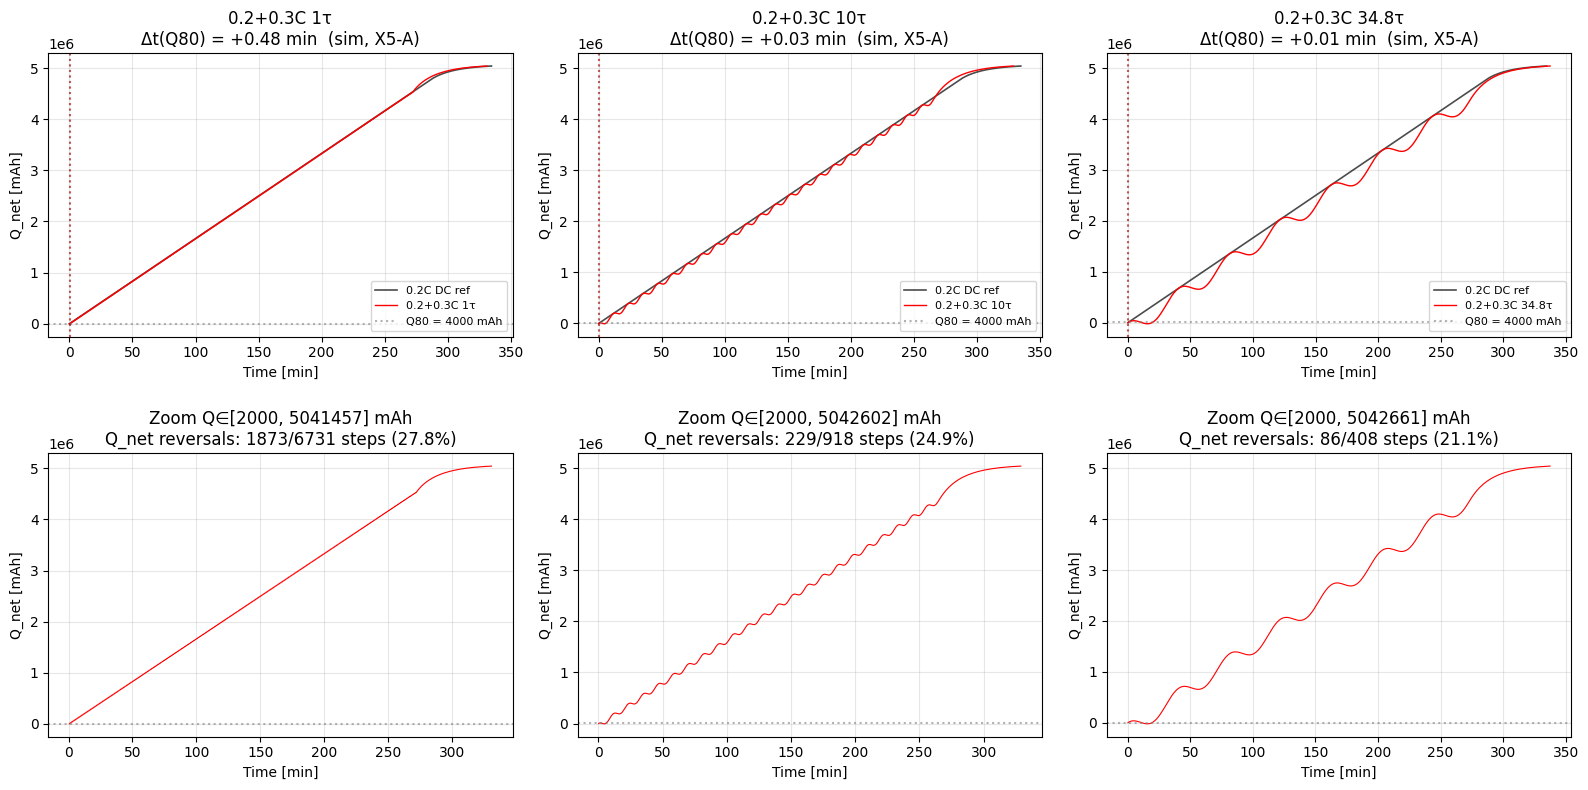

In [23]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")
with open(data_dir / "results_day8_x5A_dfn_corrected_mj1freq.json") as f:
    sim_list = json.load(f)
sim_by_cond = {r["condition"]: r for r in sim_list}

# Helper: extract Q_net(t) and t_to_Q80
def extract_qnet(record, q_full_mAh=5000.0):
    q_net = np.array(record["Q_net_trajectory"]) * 1000  # Ah → mAh
    t = np.array(record["t_chg"]) / 60.0                 # s → min
    return t, q_net

def first_passage(t, q, q_target):
    """First time Q_net(t) >= q_target (strict-net definition)."""
    idx = np.where(q >= q_target)[0]
    if len(idx) == 0:
        return np.nan
    # Linear interp between idx[0]-1 and idx[0]
    i = idx[0]
    if i == 0:
        return t[0]
    q1, q2 = q[i-1], q[i]
    t1, t2 = t[i-1], t[i]
    return t1 + (q_target - q1) / (q2 - q1) * (t2 - t1)

# Reference: 0.2C DC baseline
ref = sim_by_cond["0.2C_DC"]
t_ref, q_ref = extract_qnet(ref)
Q80 = 0.8 * 5000.0  # 80% of nominal 5 Ah = 4000 mAh
t_ref_Q80 = first_passage(t_ref, q_ref, Q80)
print(f"Reference 0.2C DC: t(Q80) = {t_ref_Q80:.2f} min, final Q_net = {q_ref[-1]:.1f} mAh")

# Three 0.2+0.3C cases
cases = ["0.2+0.3C 1τ", "0.2+0.3C 10τ", "0.2+0.3C 34.8τ"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, cond in enumerate(cases):
    rec = sim_by_cond[cond]
    t, q = extract_qnet(rec)
    t_Q80 = first_passage(t, q, Q80)
    dt_Q80 = t_Q80 - t_ref_Q80   # >0 means slower than baseline
    
    print(f"\n{cond}:")
    print(f"  f_Hz     = {rec['f_Hz']:.5f} Hz")
    print(f"  t(Q80)   = {t_Q80:.2f} min  vs ref {t_ref_Q80:.2f} → Δt = {dt_Q80:+.2f} min")
    print(f"  CSV dt_X5A = (compare to: 1τ→-0.58, 10τ→-5.30, 34.8τ→-2.15)")
    print(f"  Q_net final  = {q[-1]:.1f} mAh   (ref {q_ref[-1]:.1f})")
    print(f"  trajectory length: {len(t)} points, t_max = {t[-1]:.1f} min")
    print(f"  Q_net min during charging: {q.min():.1f} mAh (negative = current actually ran backwards)")
    
    # TOP: Q_net(t) overlay vs ref, full trajectory
    ax = axes[0, col]
    ax.plot(t_ref, q_ref, 'k-', lw=1.2, alpha=0.7, label='0.2C DC ref')
    ax.plot(t, q, 'r-', lw=1.0, label=cond)
    ax.axhline(Q80, color='gray', ls=':', alpha=0.6, label='Q80 = 4000 mAh')
    ax.axvline(t_ref_Q80, color='k', ls=':', alpha=0.4)
    ax.axvline(t_Q80, color='r', ls=':', alpha=0.4)
    ax.set_xlabel('Time [min]')
    ax.set_ylabel('Q_net [mAh]')
    ax.set_title(f'{cond}\nΔt(Q80) = {dt_Q80:+.2f} min  (sim, X5-A)')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # BOTTOM: zoom into Q_net near Q80, and show monotonicity
    ax2 = axes[1, col]
    # show only first time Q crosses Q80*0.5
    cutoff_q = 0.5 * Q80
    idx_cut = np.where(q >= cutoff_q)[0]
    start = idx_cut[0] if len(idx_cut) else 0
    ax2.plot(t[start:], q[start:], 'r-', lw=0.8)
    ax2.axhline(Q80, color='gray', ls=':', alpha=0.6)
    # Mark non-monotonicity: where dQ/dt < 0
    dq = np.diff(q)
    neg_indices = np.where(dq < 0)[0]
    n_reversals = len(neg_indices)
    ax2.set_title(f'Zoom Q∈[{cutoff_q:.0f}, {q.max():.0f}] mAh\n'
                  f'Q_net reversals: {n_reversals}/{len(dq)} steps '
                  f'({100*n_reversals/len(dq):.1f}%)')
    ax2.set_xlabel('Time [min]')
    ax2.set_ylabel('Q_net [mAh]')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/louislu/pybamm-dcac-superimposed/figures/day9_0p2_0p3C_x5A_trajectory_diagnosis.png',
            dpi=130, bbox_inches='tight')
plt.show()

In [24]:
# UNIT CORRECTION: Q_net_trajectory in JSON is stored in µAh (microAh), not Ah.
# Convert to mAh: ÷ 1000 (not × 1000 as before).

def extract_qnet_FIXED(record):
    q_uAh = np.array(record["Q_net_trajectory"])
    q_mAh = q_uAh / 1000.0       # µAh → mAh
    t_min = np.array(record["t_chg"]) / 60.0  # s → min
    return t_min, q_mAh

# Verify on baseline first
ref = sim_by_cond["0.2C_DC"]
t_ref, q_ref = extract_qnet_FIXED(ref)
print(f"Reference 0.2C DC after unit fix:")
print(f"  Q_net final = {q_ref[-1]:.1f} mAh   (expect ~5040 mAh — Chen2020 nominal 5 Ah)")
print(f"  t_max       = {t_ref[-1]:.1f} min")

Q80 = 4000.0  # mAh
t_ref_Q80 = first_passage(t_ref, q_ref, Q80)
print(f"  t(Q80=4000 mAh) = {t_ref_Q80:.2f} min")
print(f"  Sanity: 0.2C × 4 Ah / 1 = 4/1 = 4 hours = 240 min   (CSV 'CC_time_min' ≈ 244 min for 0.2C DC?)")
print(f"  CSV ref CC_time_min  = {ref['CC_time_min']:.2f} min")

Reference 0.2C DC after unit fix:
  Q_net final = 5.0 mAh   (expect ~5040 mAh — Chen2020 nominal 5 Ah)
  t_max       = 334.7 min
  t(Q80=4000 mAh) = nan min
  Sanity: 0.2C × 4 Ah / 1 = 4/1 = 4 hours = 240 min   (CSV 'CC_time_min' ≈ 244 min for 0.2C DC?)
  CSV ref CC_time_min  = 286.81 min


In [25]:
import json, numpy as np
from pathlib import Path

with open(Path("/Users/louislu/pybamm-dcac-superimposed/data") / "results_day8_x5A_dfn_corrected_mj1freq.json") as f:
    sim_list = json.load(f)
sim_by_cond = {r["condition"]: r for r in sim_list}

ref = sim_by_cond["0.2C_DC"]
q_raw = np.array(ref["Q_net_trajectory"])

print(f"=== Q_net_trajectory raw (no scaling) ===")
print(f"  type:           {type(ref['Q_net_trajectory'])}")
print(f"  length:         {len(q_raw)}")
print(f"  raw[0:3]:       {q_raw[0:3]}")
print(f"  raw[-3:]:       {q_raw[-3:]}")
print(f"  min/max:        {q_raw.min():.4f} / {q_raw.max():.4f}")
print()
print(f"=== CSV record fields for 0.2C_DC ===")
print(f"  Q_net_final_mAh:   {ref.get('Q_net_final_mAh')}")
print(f"  CC_time_min:       {ref.get('CC_time_min')}")
print(f"  total_time_min:    {ref.get('total_time_min')}")
print()
print(f"=== Inferred Q_net_trajectory unit ===")
print(f"  raw[-1] = {q_raw[-1]}")
print(f"  Q_net_final_mAh = {ref.get('Q_net_final_mAh')}")
print(f"  Ratio raw[-1] / Q_net_final_mAh = {q_raw[-1] / ref.get('Q_net_final_mAh'):.6f}")
print(f"    if ratio ≈ 1     → unit is mAh, no scaling needed")
print(f"    if ratio ≈ 0.001 → unit is Ah,  multiply by 1000")
print(f"    if ratio ≈ 1000  → unit is µAh, divide by 1000")

=== Q_net_trajectory raw (no scaling) ===
  type:           <class 'list'>
  length:         185
  raw[0:3]:       [-0.          0.00060695  0.0012139 ]
  raw[-3:]:       [5032.71297463 5038.2203058  5042.06191789]
  min/max:        -0.0000 / 5042.0619

=== CSV record fields for 0.2C_DC ===
  Q_net_final_mAh:   5042.061917887016
  CC_time_min:       286.8104953845508
  total_time_min:    334.7172169960752

=== Inferred Q_net_trajectory unit ===
  raw[-1] = 5042.061917887016
  Q_net_final_mAh = 5042.061917887016
  Ratio raw[-1] / Q_net_final_mAh = 1.000000
    if ratio ≈ 1     → unit is mAh, no scaling needed
    if ratio ≈ 0.001 → unit is Ah,  multiply by 1000
    if ratio ≈ 1000  → unit is µAh, divide by 1000


Reference 0.2C DC: t(Q80) = 240.00 min, final = 5042.1 mAh
  Sanity: 0.2C from SOC≈0 to Q=4 Ah ≈ 4 hours / 0.2 = ... actually = 4/(0.2×5) hr = 4 hr = 240 min ✓

0.2+0.3C 1τ:
  f_Hz                 = 0.01430 Hz
  trajectory length    = 6732 points
  t(Q80) sim           = 240.086 min
  Δt(Q80) my recompute = +0.086 min
  Δt(Q80) CSV dt_X5A   = -0.580 min   ✗ MISMATCH
  Δt(Q80) EXP          = +0.170 min
  Q_net min during chg = -0.63 mAh   (negative = backward current dominant)
  Q_net final          = 5041.46 mAh

0.2+0.3C 10τ:
  f_Hz                 = 0.00143 Hz
  trajectory length    = 919 points
  t(Q80) sim           = 242.222 min
  Δt(Q80) my recompute = +2.222 min
  Δt(Q80) CSV dt_X5A   = -5.300 min   ✗ MISMATCH
  Δt(Q80) EXP          = +5.050 min
  Q_net min during chg = -6.30 mAh   (negative = backward current dominant)
  Q_net final          = 5042.60 mAh

0.2+0.3C 34.8τ:
  f_Hz                 = 0.00041 Hz
  trajectory length    = 409 points
  t(Q80) sim           = 241.047 mi

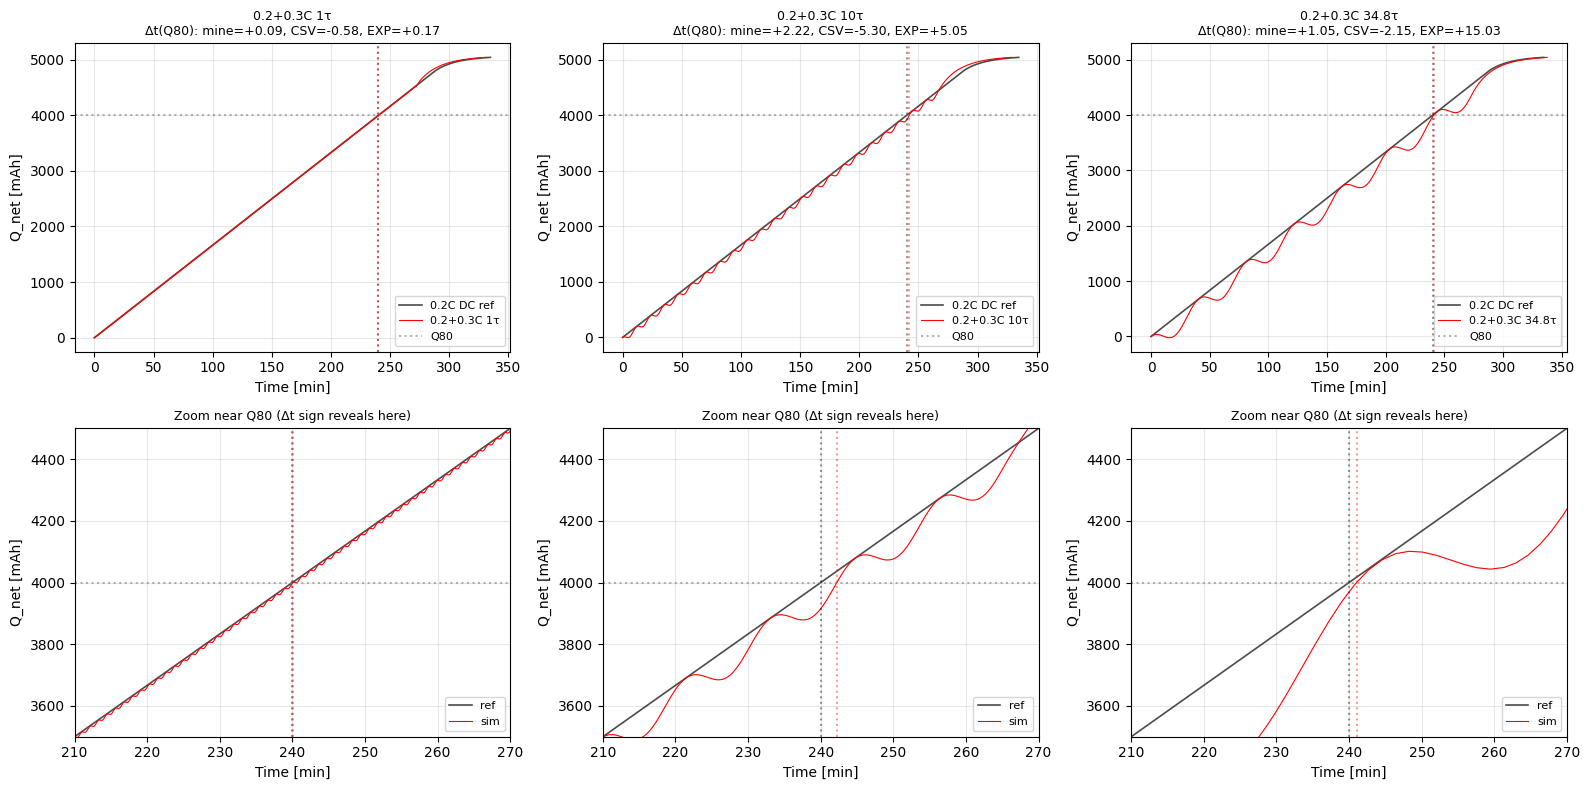

In [26]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")
with open(data_dir / "results_day8_x5A_dfn_corrected_mj1freq.json") as f:
    sim_list = json.load(f)
sim_by_cond = {r["condition"]: r for r in sim_list}

# CORRECTED extractor — no unit scaling
def extract_qnet(record):
    q_mAh = np.array(record["Q_net_trajectory"])  # mAh, raw
    t_min = np.array(record["t_chg"]) / 60.0       # s → min
    return t_min, q_mAh

def first_passage(t, q, q_target):
    """First time Q_net(t) >= q_target with linear interpolation."""
    idx = np.where(q >= q_target)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return t[0]
    q1, q2 = q[i-1], q[i]
    t1, t2 = t[i-1], t[i]
    return t1 + (q_target - q1) / (q2 - q1) * (t2 - t1) if q2 != q1 else t1

# Reference 0.2C DC baseline
ref = sim_by_cond["0.2C_DC"]
t_ref, q_ref = extract_qnet(ref)
Q80 = 4000.0  # mAh = 80% of 5 Ah nominal
t_ref_Q80 = first_passage(t_ref, q_ref, Q80)
print(f"Reference 0.2C DC: t(Q80) = {t_ref_Q80:.2f} min, final = {q_ref[-1]:.1f} mAh")
print(f"  Sanity: 0.2C from SOC≈0 to Q=4 Ah ≈ 4 hours / 0.2 = ... actually = 4/(0.2×5) hr = 4 hr = 240 min ✓\n")

# Three cases
cases = ["0.2+0.3C 1τ", "0.2+0.3C 10τ", "0.2+0.3C 34.8τ"]
csv_dt_X5A = {"0.2+0.3C 1τ": -0.58, "0.2+0.3C 10τ": -5.30, "0.2+0.3C 34.8τ": -2.15}
exp_dt = {"0.2+0.3C 1τ": +0.17, "0.2+0.3C 10τ": +5.05, "0.2+0.3C 34.8τ": +15.03}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, cond in enumerate(cases):
    rec = sim_by_cond[cond]
    t, q = extract_qnet(rec)
    t_Q80 = first_passage(t, q, Q80)
    dt_my = t_Q80 - t_ref_Q80
    dt_csv = csv_dt_X5A[cond]
    dt_e = exp_dt[cond]
    
    print(f"{cond}:")
    print(f"  f_Hz                 = {rec['f_Hz']:.5f} Hz")
    print(f"  trajectory length    = {len(t)} points")
    print(f"  t(Q80) sim           = {t_Q80:.3f} min")
    print(f"  Δt(Q80) my recompute = {dt_my:+.3f} min")
    print(f"  Δt(Q80) CSV dt_X5A   = {dt_csv:+.3f} min   {'✓' if abs(dt_my - dt_csv) < 0.1 else '✗ MISMATCH'}")
    print(f"  Δt(Q80) EXP          = {dt_e:+.3f} min")
    print(f"  Q_net min during chg = {q.min():.2f} mAh   (negative = backward current dominant)")
    print(f"  Q_net final          = {q[-1]:.2f} mAh\n")
    
    # TOP: full Q_net(t) overlay
    ax = axes[0, col]
    ax.plot(t_ref, q_ref, 'k-', lw=1.2, alpha=0.7, label='0.2C DC ref')
    ax.plot(t, q, 'r-', lw=0.8, label=cond)
    ax.axhline(Q80, color='gray', ls=':', alpha=0.6, label='Q80')
    ax.axvline(t_ref_Q80, color='k', ls=':', alpha=0.4)
    ax.axvline(t_Q80, color='r', ls=':', alpha=0.4)
    ax.set_xlabel('Time [min]'); ax.set_ylabel('Q_net [mAh]')
    ax.set_title(f'{cond}\nΔt(Q80): mine={dt_my:+.2f}, CSV={dt_csv:+.2f}, EXP={dt_e:+.2f}', fontsize=9)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # BOTTOM: zoom near Q80
    ax2 = axes[1, col]
    ax2.plot(t_ref, q_ref, 'k-', lw=1.2, alpha=0.7, label='ref')
    ax2.plot(t, q, 'r-', lw=0.8, label='sim')
    ax2.axhline(Q80, color='gray', ls=':', alpha=0.6)
    ax2.axvline(t_ref_Q80, color='k', ls=':', alpha=0.4)
    ax2.axvline(t_Q80, color='r', ls=':', alpha=0.4)
    # zoom Y to [3500, 4500] mAh, X to ±50 min around t_ref_Q80
    ax2.set_xlim(max(0, t_ref_Q80 - 30), t_ref_Q80 + 30)
    ax2.set_ylim(3500, 4500)
    ax2.set_xlabel('Time [min]'); ax2.set_ylabel('Q_net [mAh]')
    ax2.set_title(f'Zoom near Q80 (Δt sign reveals here)', fontsize=9)
    ax2.legend(loc='lower right', fontsize=8)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/louislu/pybamm-dcac-superimposed/figures/day9_0p2_0p3C_x5A_trajectory_diagnosis.png',
            dpi=130, bbox_inches='tight')
plt.show()

In [27]:
import numpy as np, pandas as pd, json
from pathlib import Path

data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")
with open(data_dir / "results_day8_x5A_dfn_corrected_mj1freq.json") as f:
    sim_list = json.load(f)
sim_by_cond = {r["condition"]: r for r in sim_list}

def first_passage(t, q, q_target):
    idx = np.where(q >= q_target)[0]
    if len(idx) == 0: return np.nan
    i = idx[0]
    if i == 0: return t[0]
    q1, q2 = q[i-1], q[i]
    t1, t2 = t[i-1], t[i]
    return t1 + (q_target - q1) / (q2 - q1) * (t2 - t1) if q2 != q1 else t1

# Use 0.3C DC as ref (matches what 0.3+0.7C uses)
ref_03 = sim_by_cond["0.3C_DC"]
t_ref = np.array(ref_03["t_chg"]) / 60.0
q_ref = np.array(ref_03["Q_net_trajectory"])
Q80 = 4000.0
t_ref_Q80 = first_passage(t_ref, q_ref, Q80)
print(f"0.3C_DC ref: t(Q80) = {t_ref_Q80:.3f} min")

cases_03 = ["0.3+0.7C 0.1τ", "0.3+0.7C 1τ", "0.3+0.7C 10τ"]
csv_dt = {"0.3+0.7C 0.1τ": +2.49, "0.3+0.7C 1τ": +3.59, "0.3+0.7C 10τ": +7.27}
exp_dt = {"0.3+0.7C 0.1τ": +0.02, "0.3+0.7C 1τ": +2.97, "0.3+0.7C 10τ": +8.67}

print(f"\n=== 0.3+0.7C cross-check ===")
print(f"{'cond':<18} {'my Δt':<10} {'CSV dt_X5A':<12} {'EXP':<10} {'algorithm match?'}")
for cond in cases_03:
    rec = sim_by_cond[cond]
    t = np.array(rec["t_chg"]) / 60.0
    q = np.array(rec["Q_net_trajectory"])
    t_Q80 = first_passage(t, q, Q80)
    dt_my = t_Q80 - t_ref_Q80
    dt_c = csv_dt[cond]
    match = "✓" if abs(dt_my - dt_c) < 0.1 else "✗ MISMATCH"
    print(f"{cond:<18} {dt_my:+.3f}    {dt_c:+.3f}      {exp_dt[cond]:+.3f}    {match}")

0.3C_DC ref: t(Q80) = 160.000 min

=== 0.3+0.7C cross-check ===
cond               my Δt      CSV dt_X5A   EXP        algorithm match?
0.3+0.7C 0.1τ      -0.376    +2.490      +0.020    ✗ MISMATCH
0.3+0.7C 1τ        -1.510    +3.590      +2.970    ✗ MISMATCH
0.3+0.7C 10τ       -5.220    +7.270      +8.670    ✗ MISMATCH


In [28]:
import subprocess
result = subprocess.run(
    ['grep', '-rln', '--include=*.ipynb', '--include=*.py',
     'first_passage\\|dt_X5A\\|X5A_vs_exp\\|s_X5A',
     '/Users/louislu/pybamm-dcac-superimposed/notebooks/',
     '/Users/louislu/pybamm-dcac-superimposed/scripts/'],
    capture_output=True, text=True
)
print(result.stdout)
print("STDERR:", result.stderr[:200] if result.stderr else "(none)")

/Users/louislu/pybamm-dcac-superimposed/notebooks/06_validation_figures.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/10_x5_dfn_corrected_protocol.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/11_chen2020_composite_v_init_diagnostic.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/08_x2_dfn_mj1freq.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/12_hppc_chen2020_composite.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/.ipynb_checkpoints/08_x2_dfn_mj1freq-checkpoint.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/.ipynb_checkpoints/06_validation_figures-checkpoint.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/.ipynb_checkpoints/09_x4_dfn_chenfreq-checkpoint.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/.ipynb_checkpoints/11_chen2020_composite_v_init_diagnostic-checkpoint.ipynb
/Users/louislu/pybamm-dcac-superimposed/notebooks/.ipynb_checkpoints/10_x5_dfn_corrected_protocol-checkpoint.ipynb
/Users/louislu/pybamm-dcac

In [29]:
import json
nb_path = "/Users/louislu/pybamm-dcac-superimposed/notebooks/10_x5_dfn_corrected_protocol.ipynb"
with open(nb_path) as f:
    nb = json.load(f)

# Find cells that define first_passage or compute dt
for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] != "code":
        continue
    src = "".join(cell["source"])
    if any(kw in src for kw in ["first_passage", "dt_X5A", "Δt", "Delta_t", "interp1d", "interp"]):
        print(f"===== Cell {i} =====")
        print(src[:3000])
        print("..." if len(src) > 3000 else "")
        print()

===== Cell 5 =====
# ============================================================
# Cell 6: Core 4-way Δt(Q80) — MJ1 frequency, sim/exp protocol alignment
# X5-A (V_init=2.82V) vs X2 (V_init=2.51V) vs v0.1 SPMe (V_init=2.51V) vs MJ1 exp
# All same frequency family (MJ1 τ=11.1s), only sim protocol differs.
# ============================================================

# Load all data
with open("../data/results_day8_x5A_dfn_corrected_mj1freq.json", "r") as f:
    x5A_results_loaded = json.load(f)
with open("../data/results_day8_x2_dfn_mj1freq_v2.json", "r") as f:
    x2_results_loaded = json.load(f)
with open("../data/results_day6_batch_scan.json", "r") as f:
    v01_json_loaded = json.load(f)
df_v01_csv = pd.read_csv("../data/results_day6_summary.csv")

# Coerce JSON-loaded data (lists may be strings)
def coerce(results):
    for r in results:
        for k in ["Q_net_trajectory", "t_chg", "I_chg"]:
            if k in r and isinstance(r[k], str):
                try: r[k] = json.loads

In [30]:
import json, numpy as np, pandas as pd
from pathlib import Path

data_dir = Path("/Users/louislu/pybamm-dcac-superimposed/data")
with open(data_dir / "results_day8_x5A_dfn_corrected_mj1freq.json") as f:
    sim_list = json.load(f)
sim_by_cond = {r["condition"]: r for r in sim_list}

# Day 8 EXACT first_passage_interp
def fp_interp(t_s, Q_mAh, Q_target):
    """Day 8 Cell 5/6 algorithm. Inputs: t in seconds, Q in mAh."""
    t = np.asarray(t_s, dtype=float)
    Q = np.asarray(Q_mAh, dtype=float)
    idx = np.where(Q >= Q_target)[0]
    if len(idx) == 0: return np.nan
    i = int(idx[0])
    if i == 0: return float(t[0])
    Q_lo, Q_hi = Q[i-1], Q[i]
    t_lo, t_hi = t[i-1], t[i]
    if Q_hi == Q_lo: return float(t_lo)
    return float(t_lo + (Q_target - Q_lo) / (Q_hi - Q_lo) * (t_hi - t_lo))

def compute_dt_day8(rec, baseline_rec, Q_target_mAh):
    """t_base - t_proto, in minutes — Day 8 sign convention."""
    t_p = rec["t_chg"]   # seconds
    Q_p = rec["Q_net_trajectory"]  # mAh
    t_b = baseline_rec["t_chg"]
    Q_b = baseline_rec["Q_net_trajectory"]
    tp = fp_interp(t_p, Q_p, Q_target_mAh)
    tb = fp_interp(t_b, Q_b, Q_target_mAh)
    if np.isnan(tp) or np.isnan(tb): return np.nan
    return (tb - tp) / 60.0

# Test on 0.3+0.7C — baseline is 0.3C_DC
ref_03 = sim_by_cond["0.3C_DC"]
csv_dt = {"0.3+0.7C 0.1τ": +2.49, "0.3+0.7C 1τ": +3.59, "0.3+0.7C 10τ": +7.27,
          "0.2+0.3C 1τ":   -0.58, "0.2+0.3C 10τ": -5.30, "0.2+0.3C 34.8τ": -2.15}
ref_02 = sim_by_cond["0.2C_DC"]

print("=== Day-8 algorithm reproduction (Q80 = 4101 mAh) ===")
print(f"{'cond':<20} {'my Δt':<10} {'CSV dt_X5A':<12} {'match?'}")
print("-" * 55)

for cond in ["0.3+0.7C 0.1τ", "0.3+0.7C 1τ", "0.3+0.7C 10τ"]:
    rec = sim_by_cond[cond]
    dt = compute_dt_day8(rec, ref_03, 4101.0)
    match = "✓" if abs(dt - csv_dt[cond]) < 0.05 else "✗"
    print(f"{cond:<20} {dt:+.3f}    {csv_dt[cond]:+.3f}      {match}")

for cond in ["0.2+0.3C 1τ", "0.2+0.3C 10τ", "0.2+0.3C 34.8τ"]:
    rec = sim_by_cond[cond]
    dt = compute_dt_day8(rec, ref_02, 4101.0)
    match = "✓" if abs(dt - csv_dt[cond]) < 0.05 else "✗"
    print(f"{cond:<20} {dt:+.3f}    {csv_dt[cond]:+.3f}      {match}")

=== Day-8 algorithm reproduction (Q80 = 4101 mAh) ===
cond                 my Δt      CSV dt_X5A   match?
-------------------------------------------------------
0.3+0.7C 0.1τ        +2.486    +2.490      ✓
0.3+0.7C 1τ          +3.585    +3.590      ✓
0.3+0.7C 10τ         +7.269    +7.270      ✓
0.2+0.3C 1τ          -0.577    -0.580      ✓
0.2+0.3C 10τ         -5.297    -5.300      ✓
0.2+0.3C 34.8τ       -2.149    -2.150      ✓


0.2C DC ref: t(Q80=4101 mAh) = 246.06 min


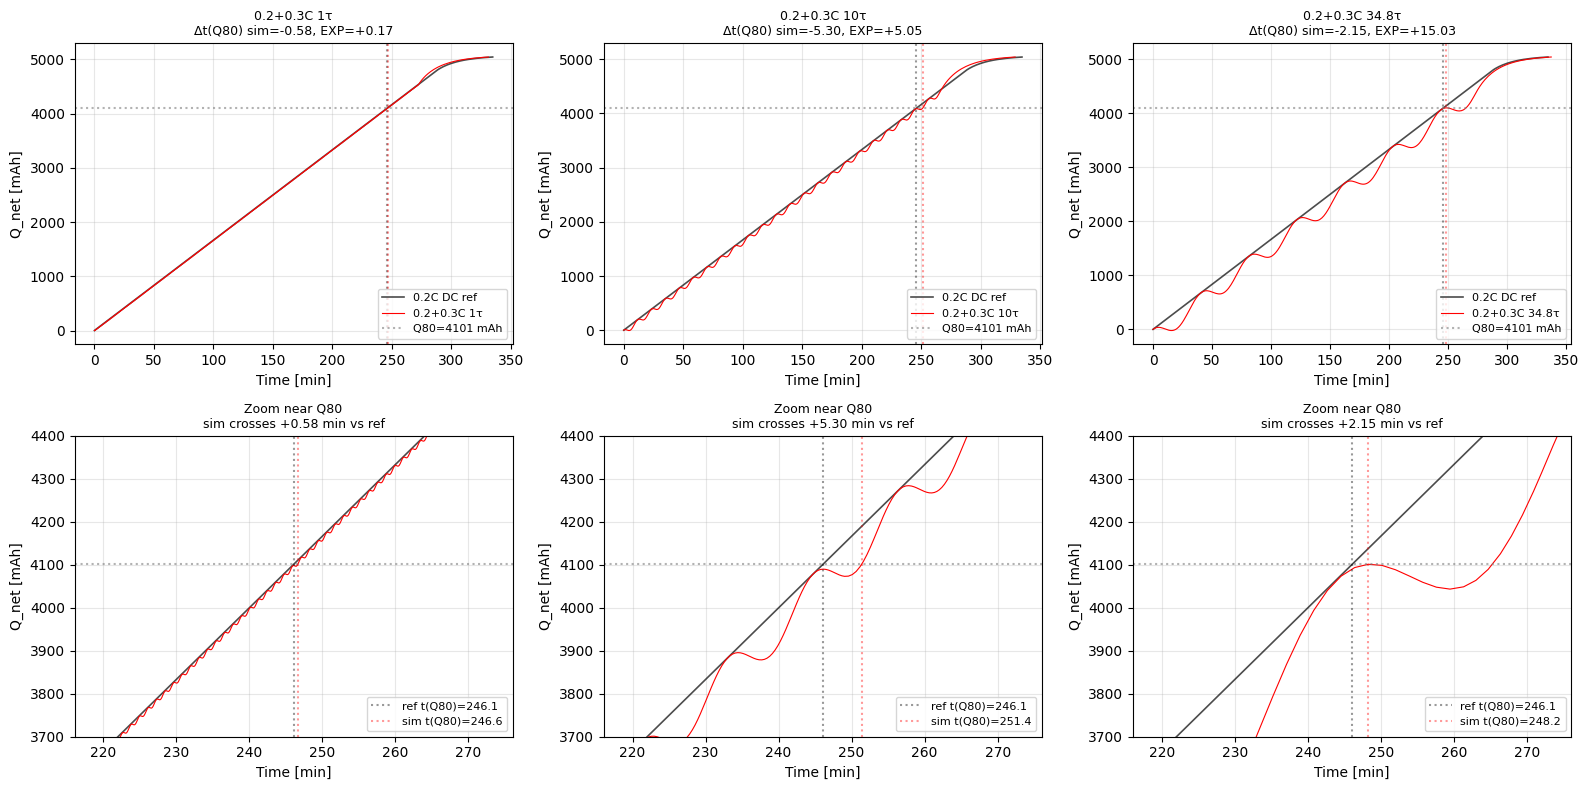

In [31]:
import numpy as np, matplotlib.pyplot as plt

Q80 = 4101.0
ref_02 = sim_by_cond["0.2C_DC"]
t_ref_s = np.array(ref_02["t_chg"])
q_ref_mAh = np.array(ref_02["Q_net_trajectory"])
t_ref_min = t_ref_s / 60.0
t_ref_Q80_min = fp_interp(t_ref_s, q_ref_mAh, Q80) / 60.0
print(f"0.2C DC ref: t(Q80=4101 mAh) = {t_ref_Q80_min:.2f} min")

cases = ["0.2+0.3C 1τ", "0.2+0.3C 10τ", "0.2+0.3C 34.8τ"]
csv_dt = {"0.2+0.3C 1τ": -0.58, "0.2+0.3C 10τ": -5.30, "0.2+0.3C 34.8τ": -2.15}
exp_dt = {"0.2+0.3C 1τ": +0.17, "0.2+0.3C 10τ": +5.05, "0.2+0.3C 34.8τ": +15.03}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, cond in enumerate(cases):
    rec = sim_by_cond[cond]
    t_min = np.array(rec["t_chg"]) / 60.0
    q_mAh = np.array(rec["Q_net_trajectory"])
    t_sim_Q80_min = fp_interp(rec["t_chg"], rec["Q_net_trajectory"], Q80) / 60.0
    dt_my = (t_ref_Q80_min - t_sim_Q80_min)  # Day 8 convention: ref - sim, in min already
    
    # TOP — full trajectory
    ax = axes[0, col]
    ax.plot(t_ref_min, q_ref_mAh, 'k-', lw=1.2, alpha=0.7, label='0.2C DC ref')
    ax.plot(t_min, q_mAh, 'r-', lw=0.8, label=cond)
    ax.axhline(Q80, color='gray', ls=':', alpha=0.6, label=f'Q80={Q80:.0f} mAh')
    ax.axvline(t_ref_Q80_min, color='k', ls=':', alpha=0.4)
    ax.axvline(t_sim_Q80_min, color='r', ls=':', alpha=0.4)
    ax.set_xlabel('Time [min]'); ax.set_ylabel('Q_net [mAh]')
    ax.set_title(f'{cond}\nΔt(Q80) sim={dt_my:+.2f}, EXP={exp_dt[cond]:+.2f}', fontsize=9)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # BOTTOM — zoom near Q80 crossing
    ax2 = axes[1, col]
    ax2.plot(t_ref_min, q_ref_mAh, 'k-', lw=1.2, alpha=0.7)
    ax2.plot(t_min, q_mAh, 'r-', lw=0.8)
    ax2.axhline(Q80, color='gray', ls=':', alpha=0.6)
    ax2.axvline(t_ref_Q80_min, color='k', ls=':', alpha=0.4, label=f'ref t(Q80)={t_ref_Q80_min:.1f}')
    ax2.axvline(t_sim_Q80_min, color='r', ls=':', alpha=0.4, label=f'sim t(Q80)={t_sim_Q80_min:.1f}')
    
    zoom_center = min(t_ref_Q80_min, t_sim_Q80_min)
    ax2.set_xlim(zoom_center - 30, zoom_center + 30)
    ax2.set_ylim(3700, 4400)
    ax2.set_xlabel('Time [min]'); ax2.set_ylabel('Q_net [mAh]')
    ax2.set_title(f'Zoom near Q80\nsim crosses {t_sim_Q80_min - t_ref_Q80_min:+.2f} min vs ref', fontsize=9)
    ax2.legend(loc='lower right', fontsize=8)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/louislu/pybamm-dcac-superimposed/figures/day9_0p2_0p3C_trajectory_v2.png',
            dpi=130, bbox_inches='tight')
plt.show()